
### TODO for January 7th/2026: 

- [ ] Improve density fits with Colosus
- [x] Improve BFE density fits
- [ ] Think about different fitting strategies.
- [ ] Softening. is the resolution limit for rmin
- [ ] Plot basis density profiles
- [ ] Make time-dependent analysis
- [ ] 2D MIRSE density plots
- [ ] Make basis grids
- [ ] Enclosed mass at different radii between different combinations of particle classification
- [ ] Think about what it the length of the expansion needed. Perhaps using S/N?

### 

[] Print the halo position of the halo as a function of time
[] Print the mass as a function of time


In [10]:
%matplotlib inline
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import splrep, BSpline
from inspect import getmembers, isfunction
# EXP-related libraries 
import pyEXP
import EXPtools
# Cosmom sims
import colossus


In [11]:
EXPtools.use_exptools_style(usetex=True)

In [12]:
snap=90
DATAFILE = './halo2/galaxies_tng50-3-dark_{:03d}.hdf5'.format(snap)
f = h5py.File(DATAFILE, 'r')
print(f.keys())

<KeysViewHDF5 ['catgrp_GroupCM', 'catgrp_GroupMassType', 'catgrp_GroupNsubs', 'catgrp_GroupPos', 'catgrp_GroupVel', 'catgrp_Group_M_Crit200', 'catgrp_Group_M_Crit500', 'catgrp_Group_M_Mean200', 'catgrp_Group_M_TopHat200', 'catgrp_Group_R_Crit200', 'catgrp_Group_R_Crit500', 'catgrp_Group_R_Mean200', 'catgrp_Group_R_TopHat200', 'catgrp_id', 'catgrp_is_primary', 'catsh_SubhaloCM', 'catsh_SubhaloGrNr', 'catsh_SubhaloHalfmassRadType', 'catsh_SubhaloMassInHalfRadType', 'catsh_SubhaloMassInRadType', 'catsh_SubhaloMassType', 'catsh_SubhaloPos', 'catsh_SubhaloSpin', 'catsh_SubhaloVel', 'catsh_SubhaloVmax', 'catsh_id', 'config', 'info', 'ptldm_Coordinates', 'ptldm_Velocities', 'ptldm_first', 'ptldm_fuzz_Coordinates', 'ptldm_fuzz_first', 'ptldm_fuzz_n', 'ptldm_n', 'ptldm_oshs_Coordinates', 'ptldm_oshs_first', 'ptldm_oshs_n', 'tree_is_primary', 'tree_subfind_id']>


In [13]:
def com_halo(snap):
    """Return the centre-of-mass position of the first group in snapshot *snap*."""
    DATAFILE = './halo2/galaxies_tng50-3-dark_{:03d}.hdf5'.format(snap)
    with h5py.File(DATAFILE, 'r') as f:
        return np.array(f['catgrp_GroupPos'][0])


def Mcrit200(snap):
    """Return M_Crit200 for the first group in snapshot *snap*."""
    DATAFILE = './halo2/galaxies_tng50-3-dark_{:03d}.hdf5'.format(snap)
    with h5py.File(DATAFILE, 'r') as f:
        return np.array(f['catgrp_Group_M_Crit200'][0])


In [5]:
j=0
nsnaps = 20
pos_com = np.zeros((nsnaps, 3))
M_200c = np.zeros(nsnaps)
for i in range(79, 79+nsnaps):
    pos_com[j] = com_halo((i))
    M_200c[j] = Mcrit200(i)
    j+=1

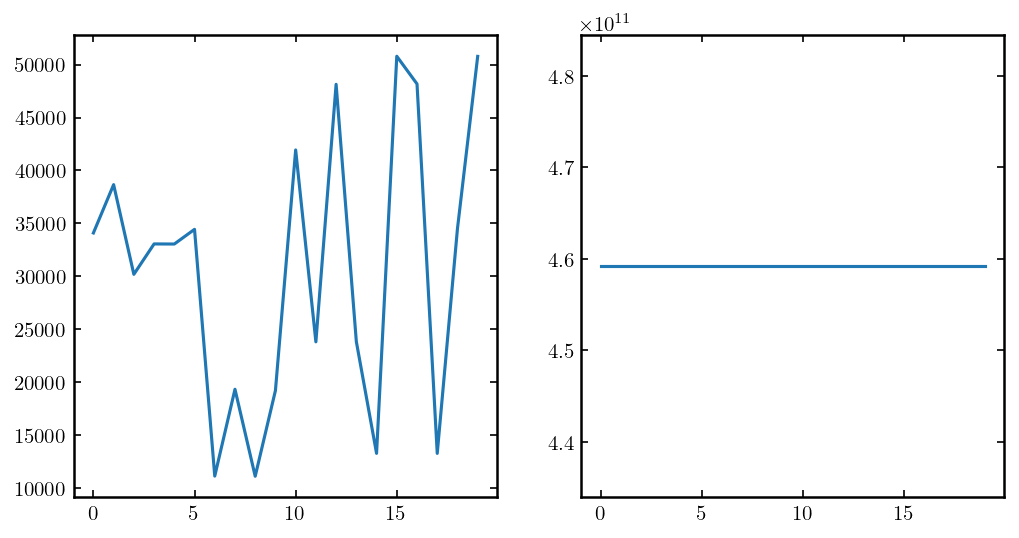

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].plot(np.linalg.norm(pos_com, axis=1))
ax[1].plot(M_200c)


In [7]:
np.array(f['catgrp_GroupCM'])

array([[19094.30859375, 14294.5       ,  1057.26135254]])

In [8]:
def find_key_coordinates(f):
    for key in f.keys():
        if key.endswith("ptldm_Coordinates"):
            k_all = key
        elif key.endswith("fuzz_Coordinates"):
            k_fuzz = key
    return k_all, k_fuzz

In [9]:
def plot_halo_particles(snap):
    DATAFILE = './halo2/galaxies_tng50-3-dark_{:03d}.hdf5'.format(snap)
    particle_mass = 3.2e8 # Msun TNG100-3
    particle_mass = 4.8e8 # Msun TNG50-3 referece: Table 1 in https://arxiv.org/pdf/1504.00362
    
    halos_particle_selection  = ['galaxy_021537_ptldm_Coordinates', 'galaxy_021537_ptldm_fuzz_Coordinates', 'galaxy_021537_ptldm_oshs_Coordinates']
    f = h5py.File(DATAFILE, 'r')
    print(f.keys())

    print(f['catsh_SubhaloMassType'][0][1]/3.2e8)
    
    fig, ax = plt.subplots(1, 2, figsize=(8,4), sharey=True)
    coord_key, fuzz_key = find_key_coordinates(f)
    #for i in range(3):
    pos = np.array(f[coord_key])
    ax[0].text(-300, -300, 'Npart={}'.format(len(pos)))
    ax[0].hist2d(pos[:,0], pos[:,1], bins=200, norm=LogNorm(), cmap='twilight');
    ax[0].set_xlim(-400, 400)
    ax[0].set_ylim(-400, 400)
    ax[0].set_title("Host's particles {:03d}".format(snap))

    pos_fuzz = np.array(f[fuzz_key])

    ax[1].text(-300, -300, 'Npart={}'.format(len(pos_fuzz)))
    ax[1].hist2d(pos_fuzz[:,0], pos_fuzz[:,1], bins=200, norm=LogNorm(), cmap='twilight');
    ax[1].set_xlim(-400, 400)
    ax[1].set_ylim(-400, 400)
    ax[1].set_title("Fuzz particles {:03d}".format(snap))


<KeysViewHDF5 ['catgrp_GroupCM', 'catgrp_GroupMassType', 'catgrp_GroupNsubs', 'catgrp_GroupPos', 'catgrp_GroupVel', 'catgrp_Group_M_Crit200', 'catgrp_Group_M_Crit500', 'catgrp_Group_M_Mean200', 'catgrp_Group_M_TopHat200', 'catgrp_Group_R_Crit200', 'catgrp_Group_R_Crit500', 'catgrp_Group_R_Mean200', 'catgrp_Group_R_TopHat200', 'catgrp_id', 'catgrp_is_primary', 'catsh_SubhaloCM', 'catsh_SubhaloGrNr', 'catsh_SubhaloHalfmassRadType', 'catsh_SubhaloMassInHalfRadType', 'catsh_SubhaloMassInRadType', 'catsh_SubhaloMassType', 'catsh_SubhaloPos', 'catsh_SubhaloSpin', 'catsh_SubhaloVel', 'catsh_SubhaloVmax', 'catsh_id', 'config', 'info', 'ptldm_Coordinates', 'ptldm_Velocities', 'ptldm_first', 'ptldm_fuzz_Coordinates', 'ptldm_fuzz_first', 'ptldm_fuzz_n', 'ptldm_n', 'ptldm_oshs_Coordinates', 'ptldm_oshs_first', 'ptldm_oshs_n', 'tree_is_primary', 'tree_subfind_id']>
2.3692422157364117
<KeysViewHDF5 ['catgrp_GroupCM', 'catgrp_GroupMassType', 'catgrp_GroupNsubs', 'catgrp_GroupPos', 'catgrp_GroupVel', 

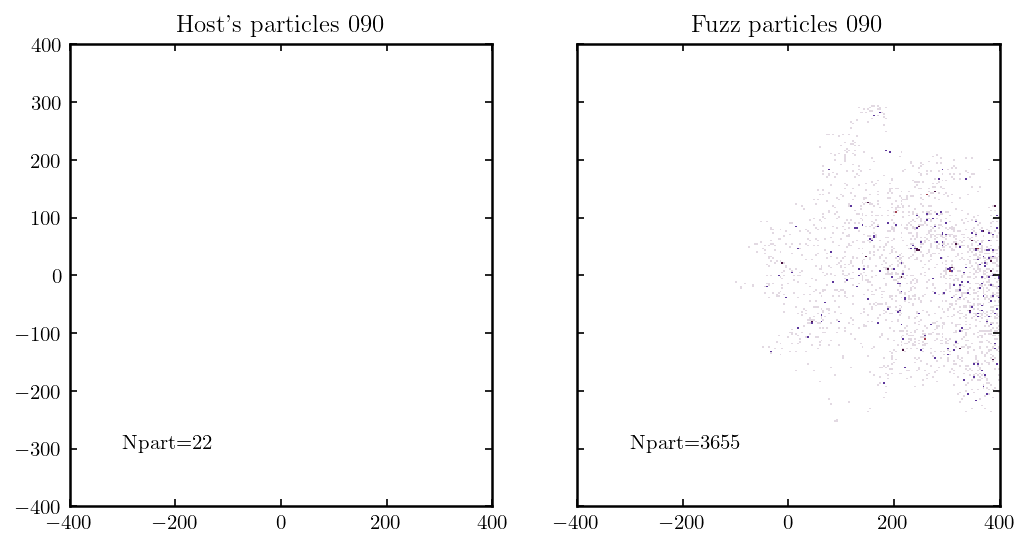

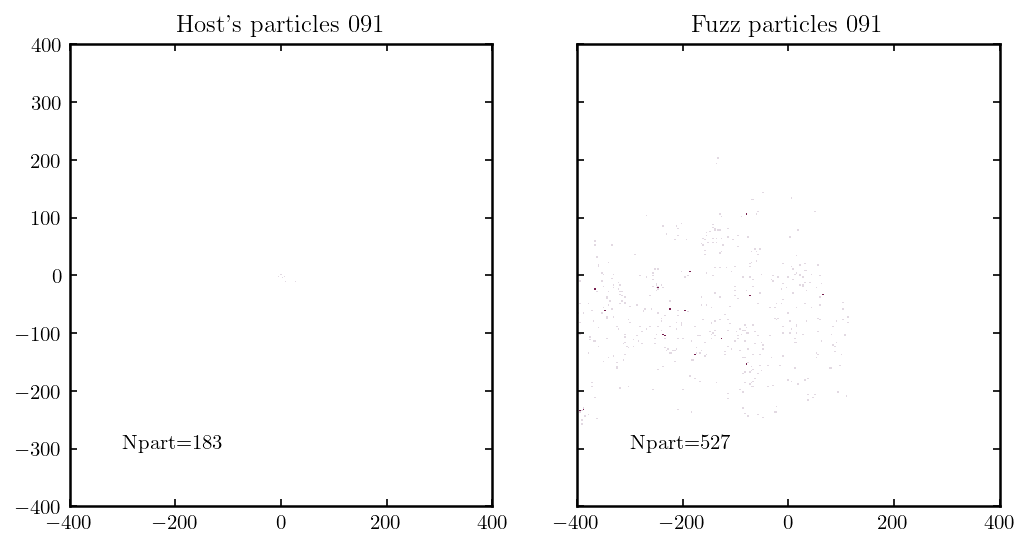

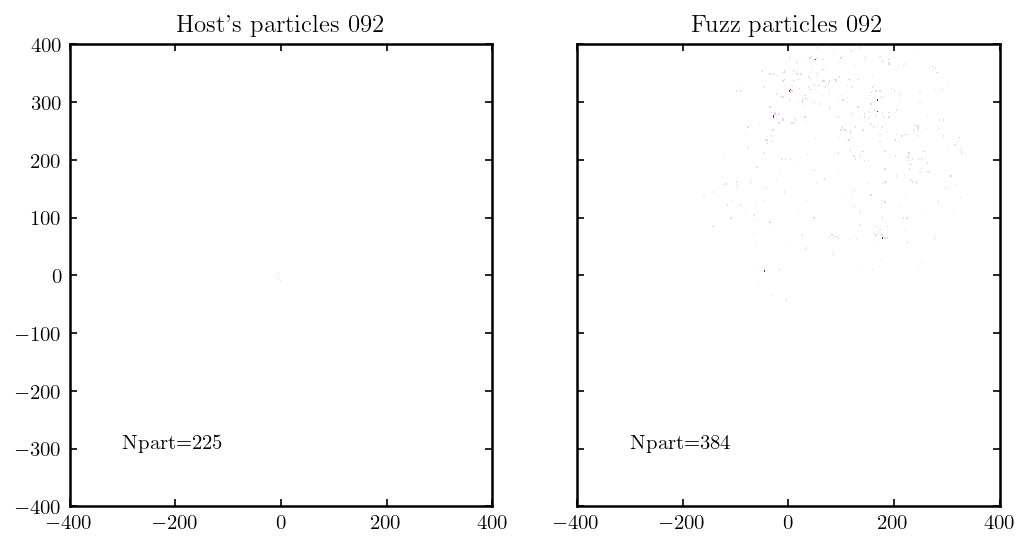

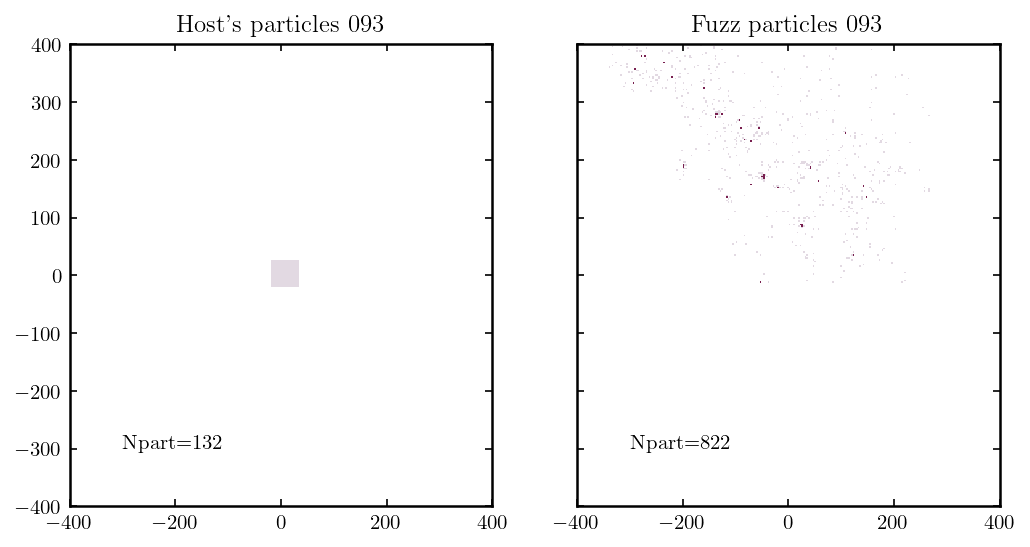

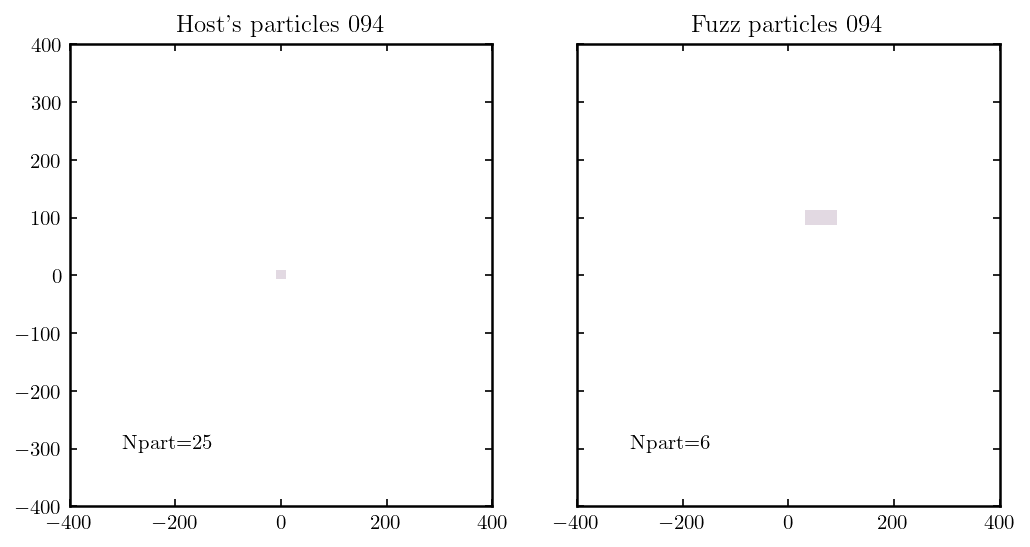

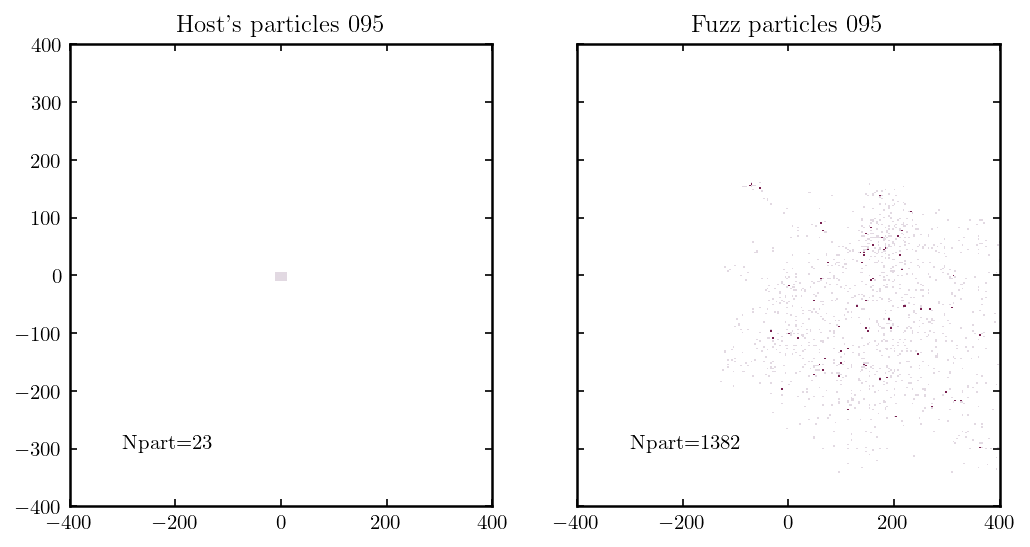

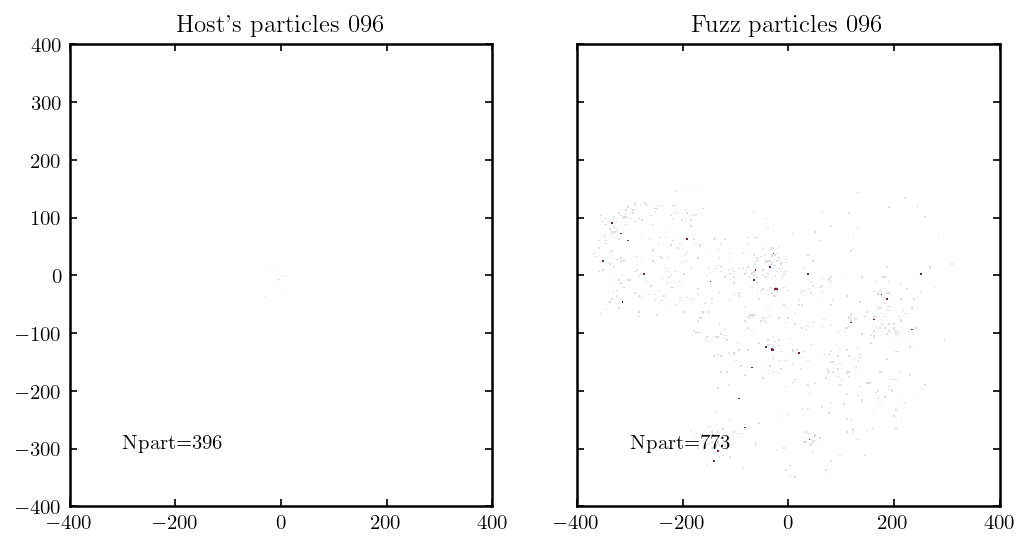

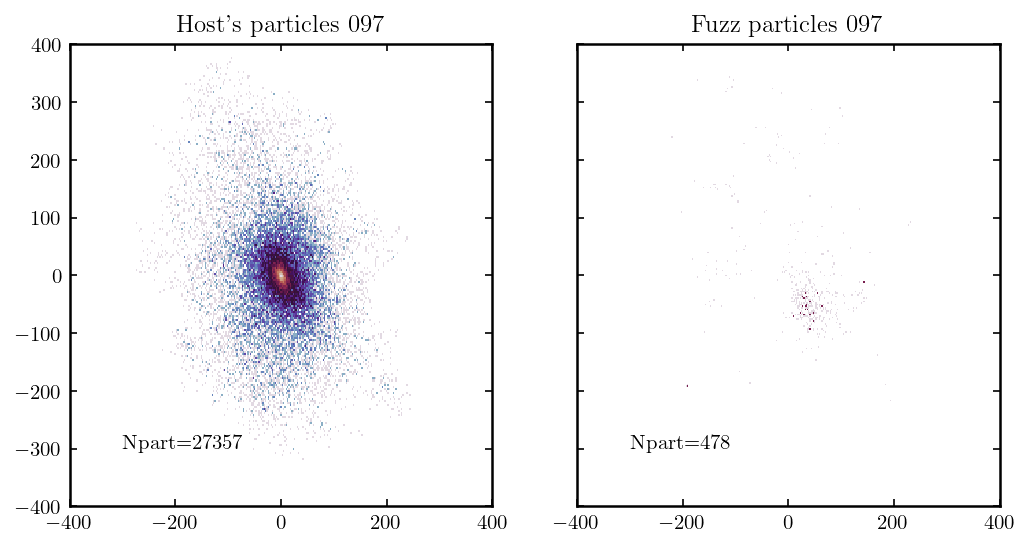

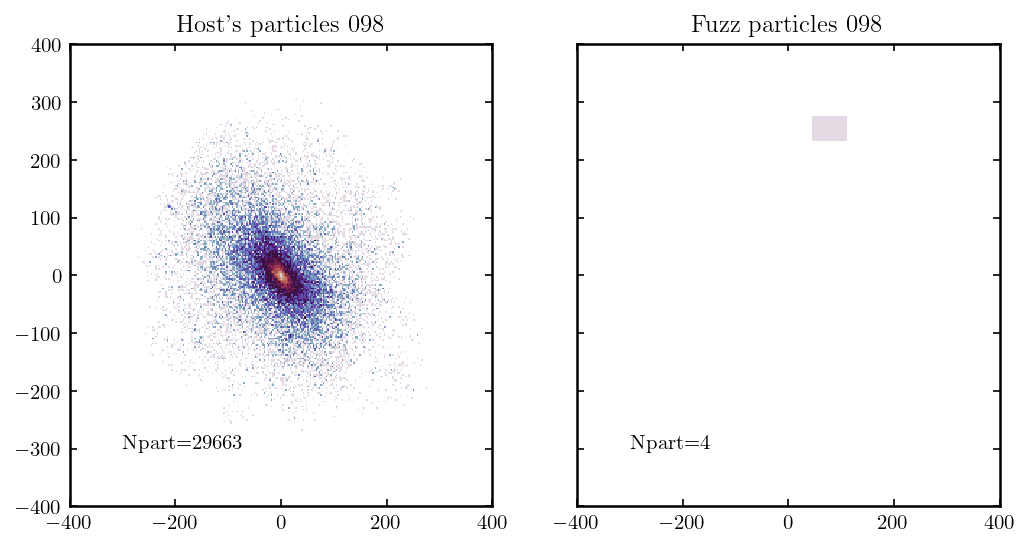

In [11]:
for i in range(90, 99):
    plot_halo_particles(i)


In [10]:
# get profiles from hydrotools 